In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]

train = pd.read_csv('../data/KDDTrain+.txt', names=columns).drop(columns=['difficulty'])
test  = pd.read_csv('../data/KDDTest+.txt',  names=columns).drop(columns=['difficulty'])

dos   = ['back','land','neptune','pod','smurf','teardrop']
probe = ['ipsweep','nmap','portsweep','satan']
r2l   = ['ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient','warezmaster']
u2r   = ['buffer_overflow','loadmodule','perl','rootkit']

def map_label(label):
    if label == 'normal': return 'normal'
    if label in dos:      return 'DoS'
    if label in probe:    return 'Probe'
    if label in r2l:      return 'R2L'
    if label in u2r:      return 'U2R'
    return 'other'

train['label'] = train['label'].apply(map_label)
test['label']  = test['label'].apply(map_label)

train = train[train['label'] != 'other']
test  = test[test['label']  != 'other']

cat_cols = ['protocol_type', 'service', 'flag']
le_feat = LabelEncoder()
for col in cat_cols:
    combined = pd.concat([train[col], test[col]])
    le_feat.fit(combined)
    train[col] = le_feat.transform(train[col])
    test[col]  = le_feat.transform(test[col])

le_label = LabelEncoder()
le_label.fit(pd.concat([train['label'], test['label']]))
train['label'] = le_label.transform(train['label'])
test['label']  = le_label.transform(test['label'])

feature_names = [c for c in train.columns if c != 'label']
class_names   = list(le_label.classes_)

X_train = train[feature_names]
y_train = train['label']
X_test  = test[feature_names]
y_test  = test['label']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

xgb = XGBClassifier(n_estimators=100, random_state=42,
                    eval_metric='mlogloss', n_jobs=-1)
xgb.fit(X_res, y_res)

print("Classes:", class_names)
print("Model ready for SHAP")

Classes: ['DoS', 'Probe', 'R2L', 'U2R', 'normal']
Model ready for SHAP


In [13]:
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
sample    = X_test_df.sample(300, random_state=42)

explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(sample)

# shap_values shape: (n_samples, n_features, n_classes)
print("SHAP values shape:", np.array(shap_values).shape)
print("Classes:", class_names)

SHAP values shape: (300, 41, 5)
Classes: ['DoS', 'Probe', 'R2L', 'U2R', 'normal']


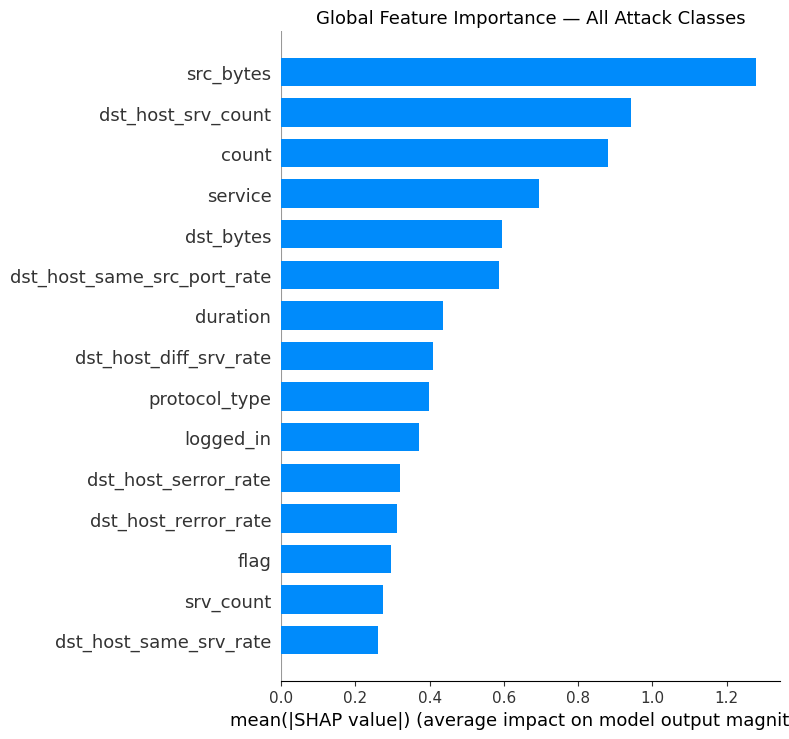

Saved to shap_global.png


In [14]:
mean_shap = np.mean(np.abs(shap_values), axis=2)

plt.figure(figsize=(9, 6))
shap.summary_plot(mean_shap, sample,
                  feature_names=feature_names,
                  plot_type="bar",
                  max_display=15,
                  show=False)
plt.title("Global Feature Importance — All Attack Classes", fontsize=13)
plt.tight_layout()
plt.savefig('../shap_global.png', dpi=150)
plt.show()
print("Saved to shap_global.png")

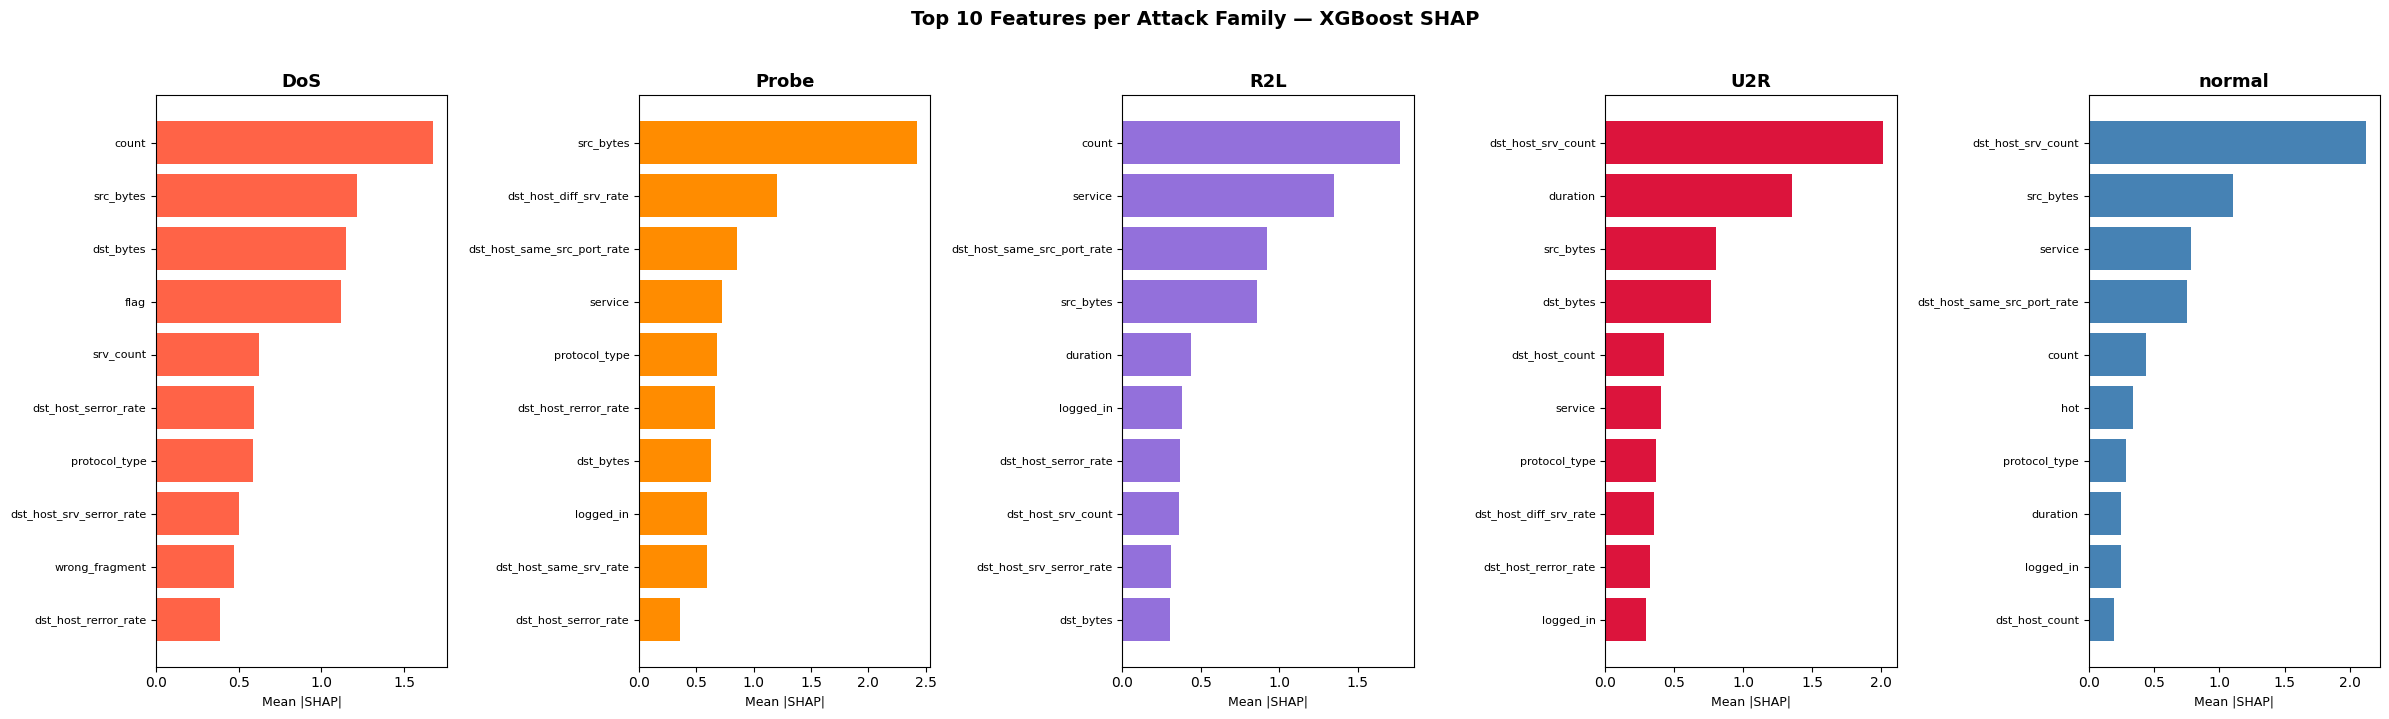

Saved to shap_per_class.png


In [15]:
fig, axes = plt.subplots(1, 5, figsize=(24, 7))
colors = {'DoS': 'tomato', 'Probe': 'darkorange',
          'R2L': 'mediumpurple', 'U2R': 'crimson', 'normal': 'steelblue'}

for i, cls in enumerate(class_names):
    sv       = shap_values[:, :, i]
    mean_abs = np.abs(sv).mean(axis=0)
    top_idx  = np.argsort(mean_abs)[::-1][:10]

    axes[i].barh(
        [feature_names[j] for j in top_idx][::-1],
        mean_abs[top_idx][::-1],
        color=colors.get(cls, 'steelblue')
    )
    axes[i].set_title(cls, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Mean |SHAP|', fontsize=9)
    axes[i].tick_params(axis='y', labelsize=8)

plt.suptitle('Top 10 Features per Attack Family — XGBoost SHAP',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../shap_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to shap_per_class.png")

Saved DoS
Saved Probe
Saved R2L
Saved U2R
Saved normal


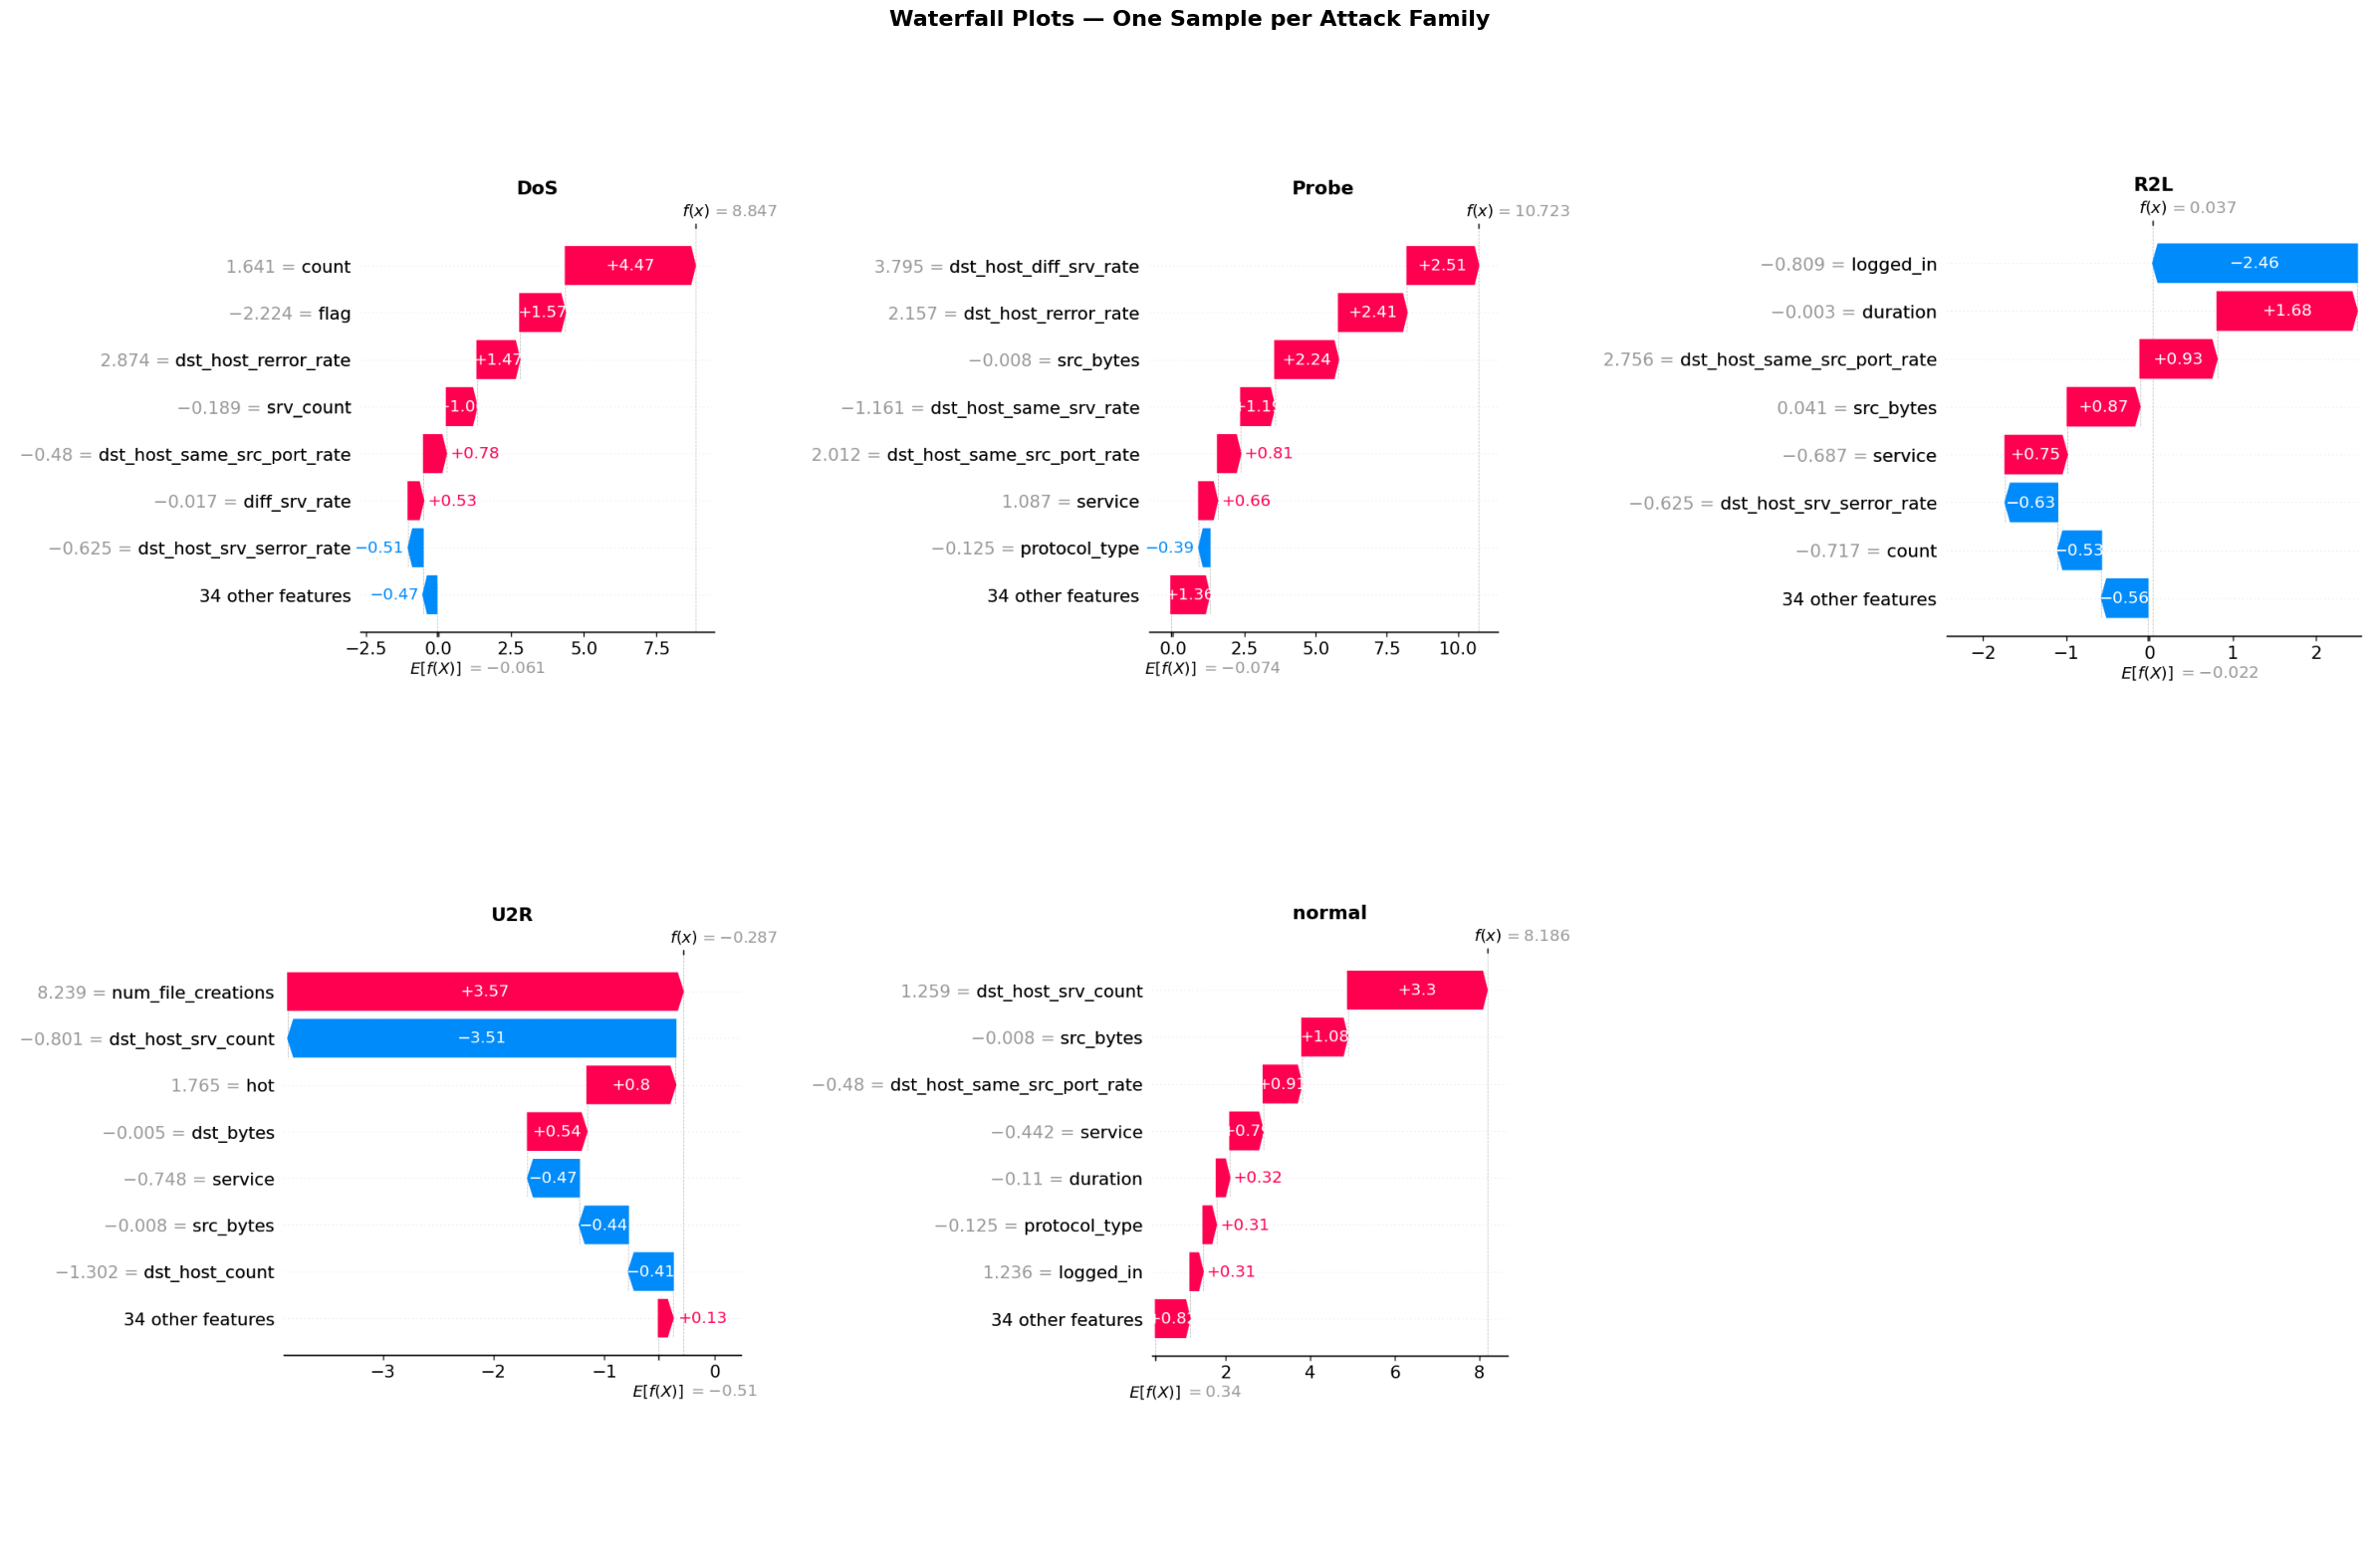

Final grid saved to shap_waterfall_per_class.png


In [18]:
import matplotlib.image as mpimg
from pathlib import Path

preds         = xgb.predict(sample)
full_test_df  = pd.DataFrame(X_test_scaled, columns=feature_names)
full_shap     = explainer.shap_values(full_test_df)
full_preds    = xgb.predict(full_test_df)

# Step 1 — save each waterfall as its own clean PNG
saved_paths = {}

for i, cls in enumerate(class_names):
    if cls == 'U2R':
        search_preds = full_preds
        search_shap  = full_shap
        search_data  = full_test_df
    else:
        search_preds = preds
        search_shap  = shap_values
        search_data  = sample

    candidates = np.where(search_preds == i)[0]
    if len(candidates) == 0:
        print(f"No sample found for {cls}")
        continue

    idx = candidates[0]
    exp = shap.Explanation(
        values        = search_shap[idx, :, i],
        base_values   = explainer.expected_value[i],
        data          = search_data.iloc[idx].values,
        feature_names = feature_names
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    shap.plots.waterfall(exp, max_display=8, show=False)
    plt.title(cls, fontsize=14, fontweight='bold')
    plt.tight_layout()
    path = f'../waterfall_{cls}.png'
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.close()
    saved_paths[cls] = path
    print(f"Saved {cls}")

# Step 2 — stitch into one clean grid
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
axes = axes.flatten()

for i, cls in enumerate(class_names):
    if cls in saved_paths:
        img = mpimg.imread(saved_paths[cls])
        axes[i].imshow(img)
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, f'{cls}\n(no sample found)',
                     ha='center', va='center', fontsize=12)
        axes[i].axis('off')

axes[5].axis('off')

plt.suptitle('Waterfall Plots — One Sample per Attack Family',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../shap_waterfall_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final grid saved to shap_waterfall_per_class.png")